<a href="https://colab.research.google.com/github/chanindu34/Fraud-Detection/blob/main/Fraud_Detector.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import io
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,classification_report

csv_data = """Amount,Distance_km,Hour_of_Day,Is_Fraud
1500,5,14,0
85000,1200,2,1
200,1,9,0
92000,5000,3,1
1200,10,18,0
45000,800,23,1
300,2,11,0
78000,2000,4,1
5000,15,15,0
150,0,8,0"""

df = pd.read_csv(io.StringIO(csv_data))
print("--- RAW SECURITY LOGS ---")
print(df.head(), "\n")

X= df[['Amount','Distance_km','Hour_of_Day']]
y= df['Is_Fraud']

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size =0.2 , random_state =42)
model = LogisticRegression()
model.fit(X_train,y_train)

print (f'---AI CLASSIFIER TRAINED---')
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test,y_pred)
print(f"Accuracy: {accuracy}")

--- RAW SECURITY LOGS ---
   Amount  Distance_km  Hour_of_Day  Is_Fraud
0    1500            5           14         0
1   85000         1200            2         1
2     200            1            9         0
3   92000         5000            3         1
4    1200           10           18         0 

---AI CLASSIFIER TRAINED---
Accuracy: 1.0


In [3]:
import pandas as pd


threat_data = pd.DataFrame(
    [[250000, 3500, 3]],
    columns=['Amount', 'Distance_km', 'Hour_of_Day']
)


new_pred = model.predict(threat_data)


print("--- LIVE THREAT ANALYSIS ---")
if new_pred[0] == 1:
    print("🚨 STATUS: FRAUD DETECTED (1) - TRANSACTION BLOCKED 🚨")
else:
    print("✅ STATUS: SAFE (0) - TRANSACTION APPROVED")

--- LIVE THREAT ANALYSIS ---
🚨 STATUS: FRAUD DETECTED (1) - TRANSACTION BLOCKED 🚨


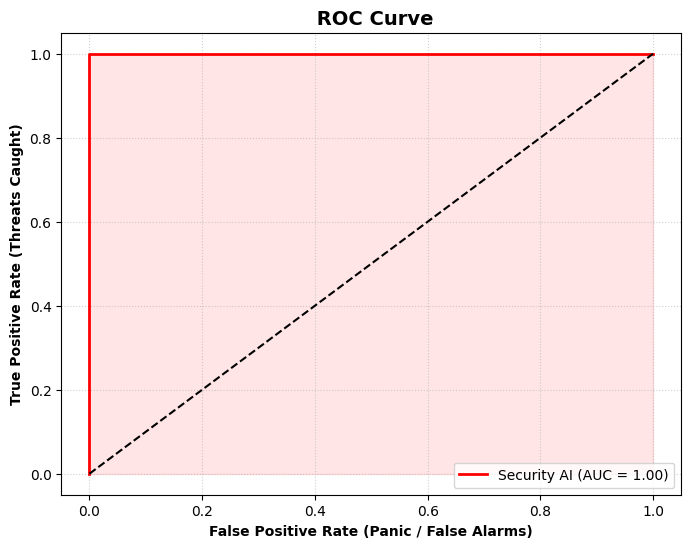

In [5]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# 1. THE CONFIDENCE EXTRACTION
# Instead of predicting 1 or 0, we ask the AI for its probability scores
y_probabilities = model.predict_proba(X_test)[:, 1]

# 2. THE MATHEMATICAL CURVE
# Calculating the False Positive Rate (Panic) vs True Positive Rate (Security Net)
fpr, tpr, thresholds = roc_curve(y_test, y_probabilities)

# 3. THE AUC SCORE (Area Under the Curve)
roc_auc = auc(fpr, tpr)

# 4. RENDERING THE ENTERPRISE DASHBOARD
plt.figure(figsize=(8, 6), facecolor='white')
plt.plot(fpr, tpr, color='red', linewidth=2, label=f'Security AI (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='black', linestyle='--') # The 50/50 Coin Flip Line
plt.fill_between(fpr, tpr, alpha=0.1, color='red')

# Formatting the output for a Tech Lead presentation
plt.xlabel('False Positive Rate (Panic / False Alarms)', fontweight='bold')
plt.ylabel('True Positive Rate (Threats Caught)', fontweight='bold')
plt.title(' ROC Curve', fontweight='bold', fontsize=14)
plt.legend(loc="lower right")
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()